# RiMEA 12d: Bottleneck Width and Flow

This notebook demonstrates the current public implementation of RiMEA Test 12d. We load one base bottleneck scenario, vary the bottleneck width, run the simulation for each width, and compute the mean flow at the bottleneck with PedPy.

Widths used in this notebook:

- `0.8 m`
- `1.0 m`
- `1.2 m`

The final plot compares the measured flow $J$ with the simple reference line $J = 1.9 w$.

In [19]:
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pedpy

from core.scenario import Scenario, load_scenario, run_scenario

In [20]:
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "#f7f7f5",
        "axes.edgecolor": "#3a3a3a",
        "axes.labelcolor": "#1d1d1d",
        "axes.titleweight": "bold",
        "xtick.color": "#1d1d1d",
        "ytick.color": "#1d1d1d",
        "font.size": 11,
    }
)

SCENARIO_DIR = Path("scenarios") / "rimea-12d-bottleneck"
WIDTHS = [0.8, 1.0, 1.2]
FRAME_STEP = 10
DELTA_FRAME = 30


## Load the Base Scenario

The scenario directory contains the shared distribution, exit, and route. The base geometry uses a `1.0 m` bottleneck, and the notebook clones it in memory for the other widths.

In [21]:
base_scenario = load_scenario(str(SCENARIO_DIR))
print(base_scenario.summary())

Scenario: /Users/chraibi/workspace/PedestrianDynamics/Web-Based-Jupedsim-issues/scripts/scenarios/rimea-12d-bottleneck
  Model:         CollisionFreeSpeedModel
  Seed:          42
  Max time:      600s
  Exits:         1
  Distributions: 1
  Stages:        0
  Zones:         0
  Journeys:      1
  Agents:        ~50
  Journey elems: 2
  Route:         1 distribution, 0 checkpoint, 1 exit
  Sequence:      jps-distributions_0 -> jps-exits_0
    jps-distributions_0: 50 agents


## Helper Functions

We deep-copy the loaded raw scenario before creating each width variant. This keeps nested configuration changes isolated, so one run cannot accidentally mutate the next one.

In [22]:
def make_geometry(width: float) -> str:
    half_width = width / 2.0
    center_y = 5.0
    return (
        f"POLYGON ((0 0, 10 0, 10 {center_y - half_width}, 15 {center_y - half_width}, "
        f"15 0, 25 0, 25 10, 15 10, 15 {center_y + half_width}, "
        f"10 {center_y + half_width}, 10 10, 0 10, 0 0))"
    )


def measurement_line(width: float) -> pedpy.MeasurementLine:
    half_width = width / 2.0
    center_y = 5.0
    measurement_line_x = 10
    return pedpy.MeasurementLine(
        [(measurement_line_x, center_y - half_width), (measurement_line_x, center_y + half_width)]
    )


def clone_scenario(base: Scenario, raw: dict, walkable_area_wkt: str, source_path: str) -> Scenario:
    sim_params = raw.get("config", {})\
        .get("simulation_settings", {})\
        .get("simulationParams", base.sim_params)
    return Scenario(
        raw=raw,
        walkable_area_wkt=walkable_area_wkt,
        model_type=sim_params.get("model_type", base.model_type),
        seed=raw.get("config", {})
        .get("simulation_settings", {})
        .get("baseSeed", base.seed),
        sim_params=deepcopy(sim_params),
        source_path=source_path,
    )


def run_width_variant(base: Scenario, width: float) -> dict:
    raw = deepcopy(base.raw)
    variant = clone_scenario(
        base,
        raw=raw,
        walkable_area_wkt=make_geometry(width),
        source_path=f"rimea-12d-bottleneck-w{width:.1f}",
    )
    result = run_scenario(variant, seed=42)
    traj = pedpy.TrajectoryData(
        result.trajectory_dataframe()[["id", "frame", "x", "y"]].copy(),
        frame_rate=result.frame_rate,
    )
    line = measurement_line(width)
    nt, crossing = pedpy.compute_n_t(traj_data=traj, measurement_line=line)
    individual_speed_single_sided = pedpy.compute_individual_speed(
        traj_data=traj,
        frame_step=FRAME_STEP,
        compute_velocity=True,
        speed_calculation=pedpy.SpeedCalculation.BORDER_SINGLE_SIDED,
    )
    flow = pedpy.compute_flow(
        nt=nt,
        crossing_frames=crossing,
        individual_speed=individual_speed_single_sided,
        delta_frame=DELTA_FRAME,
        frame_rate=traj.frame_rate,
    )
    metrics = dict(result.metrics)
    result.cleanup()
    return {
        "width": width,
        "line": line,
        "walkable_area": pedpy.WalkableArea(variant.walkable_polygon),
        "trajectory": traj,
        "nt": nt,
        "crossing": crossing,
        "flow": flow,
        "mean_flow": float(flow["flow"].mean()),
        "metrics": metrics,
    }


## Run the Width Sweep

In [23]:
%%capture
runs = [run_width_variant(base_scenario, width) for width in WIDTHS]
summary_rows = [
    {
        "width_m": run["width"],
        "mean_flow_1_per_s": round(run["mean_flow"], 3),
        "evacuation_time_s": round(run["metrics"]["evacuation_time"], 2),
        "agents_evacuated": run["metrics"]["agents_evacuated"],
    }
    for run in runs
]
summary_rows

## Plot Geometries and Trajectories

Before comparing the mean flow values, we can inspect the three bottleneck widths directly. Each panel shows the room geometry, the bottleneck measurement line, and the simulated trajectories for that width.

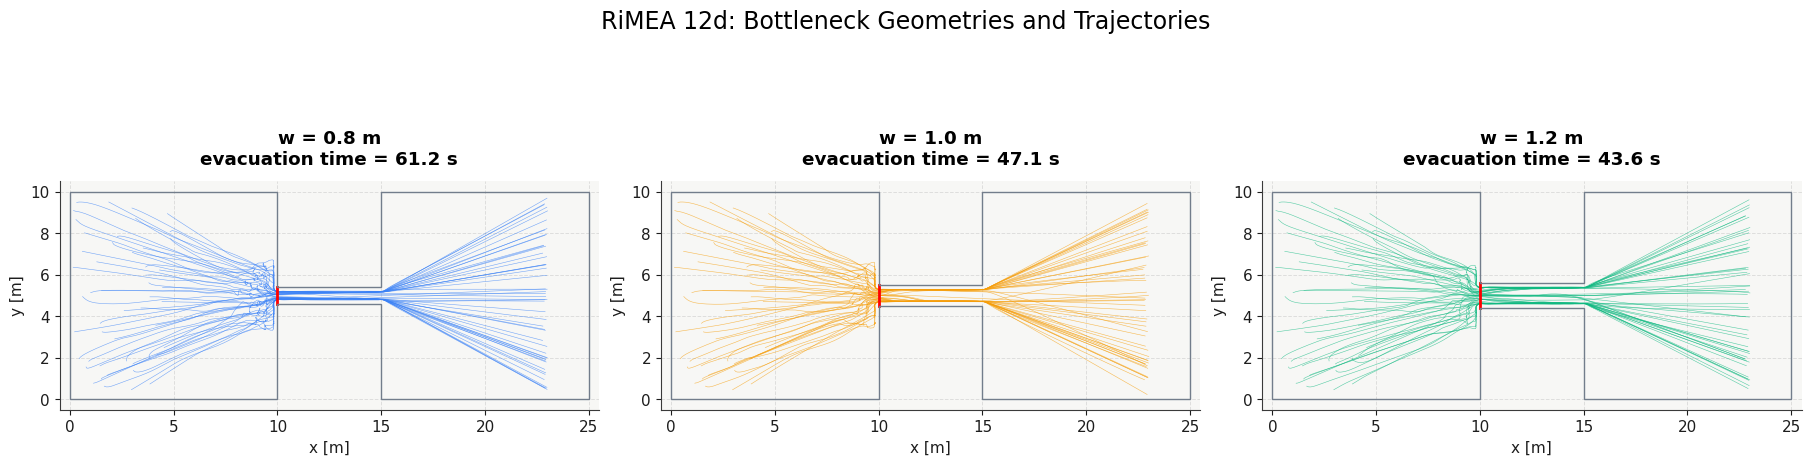

In [ ]:
TRAJECTORY_COLORS = {
    0.8: "#3B82F6",
    1.0: "#F59E0B",
    1.2: "#10B981",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), constrained_layout=True)

for ax, run in zip(axes, runs):
    color = TRAJECTORY_COLORS[run["width"]]
    pedpy.plot_measurement_setup(
        traj=run["trajectory"],
        walkable_area=run["walkable_area"],
        measurement_lines=[run["line"]],
        axes=ax,
        traj_alpha=0.7,
        traj_width=0.4,
        ml_width=2,
        ml_alpha=0.2,
        traj_color=color,
        ml_color="red",
    ).set_aspect("equal")
    ax.set_title(
        f"w = {run['width']:.1f} m\n"
        f"evacuation time = {run['metrics']['evacuation_time']:.1f} s",
        pad=12,
    )
    ax.set_xlim(-0.5, 25.5)
    ax.set_ylim(-0.5, 10.5)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("RiMEA 12d: Bottleneck Geometries and Trajectories", fontsize=17, y=1.02)
plt.show()

## Plot Flow Against Bottleneck Width

The colored line shows the mean PedPy flow for each simulated width. The dashed line is the simple reference $J = 1.9 w$.

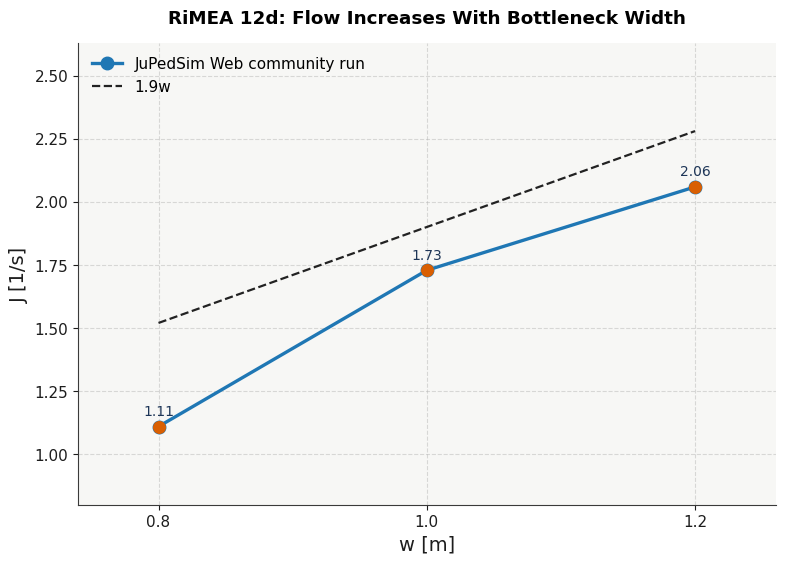

In [25]:
widths = np.array([run["width"] for run in runs], dtype=float)
flows = np.array([run["mean_flow"] for run in runs], dtype=float)
reference = 1.9 * widths

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(
    widths,
    flows,
    color="#1f77b4",
    linewidth=2.4,
    marker="o",
    markersize=9,
    label="JuPedSim Web community run",
)
ax.scatter(widths, flows, color="#d95f02", s=70, zorder=3)
ax.plot(widths, reference, linestyle="--", color="#222222", linewidth=1.6, label="1.9w")

for width, flow in zip(widths, flows):
    ax.annotate(
        f"{flow:.2f}",
        (width, flow),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        color="#1d3557",
        fontsize=10,
    )

ax.set_title("RiMEA 12d: Flow Increases With Bottleneck Width", pad=14)
ax.set_xlabel("w [m]", fontsize=14)
ax.set_ylabel("J [1/s]", fontsize=14)
ax.set_xticks(widths)
ax.set_xlim(0.74, 1.26)
ax.set_ylim(0.8, max(reference.max(), flows.max()) + 0.35)
ax.grid(True, linestyle="--", linewidth=0.8, alpha=0.45)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, loc="upper left")
plt.show()